In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dark Side of Social Media.csv")

# Quick check
print(df.shape)
print(df.columns)
df.head()


(1000, 31)
Index(['UserID', 'Age', 'Gender', 'Location', 'Income', 'Debt',
       'Owns Property', 'Profession', 'Demographics', 'Platform',
       'Total Time Spent', 'Number of Sessions', 'Video ID', 'Video Category',
       'Video Length', 'Engagement', 'Importance Score', 'Time Spent On Video',
       'Number of Videos Watched', 'Scroll Rate', 'Frequency',
       'ProductivityLoss', 'Satisfaction', 'Watch Reason', 'DeviceType', 'OS',
       'Watch Time', 'Self Control', 'Addiction Level', 'CurrentActivity',
       'ConnectionType'],
      dtype='object')


,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,...,ProductivityLoss,Satisfaction,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType
0,1,56,Male,Pakistan,82812,True,True,Engineer,Rural,Instagram,...,3,7,Procrastination,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
1,2,46,Female,Mexico,27999,False,True,Artist,Urban,Instagram,...,5,5,Habit,Computer,Android,5:00 PM,7,3,At school,Wi-Fi
2,3,32,Female,United States,42436,False,True,Engineer,Rural,Facebook,...,6,4,Entertainment,Tablet,Android,2:00 PM,8,2,At home,Mobile Data
3,4,60,Male,Barzil,62963,True,False,Waiting staff,Rural,YouTube,...,3,7,Habit,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
4,5,25,Male,Pakistan,22096,False,True,Manager,Urban,TikTok,...,8,2,Boredom,Smartphone,iOS,8:00 AM,10,0,At home,Mobile Data


In [3]:
# Target column
target_col = "ProductivityLoss"

# Drop ID-like columns that don't help
drop_cols = [c for c in ["UserID", "Video ID"] if c in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

# Drop rows with missing target
df = df.dropna(subset=[target_col])

y = df[target_col]
X = df.drop(columns=[target_col])


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
import pandas as pd
from sklearn.pipeline import Pipeline

# Define models
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

results = {}

# Train and evaluate
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = sqrt(mean_squared_error(y_test, preds))   # ✅ fixed for sklearn >= 1.5
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

# Show results
pd.DataFrame(results).T


,MAE,RMSE,R2
LinearRegression,2.633449e-15,3.314941e-15,1.000000
RandomForest,3.933333e-03,5.562573e-02,0.999405
HistGradientBoosting,5.128575e-05,6.115017e-05,1.000000


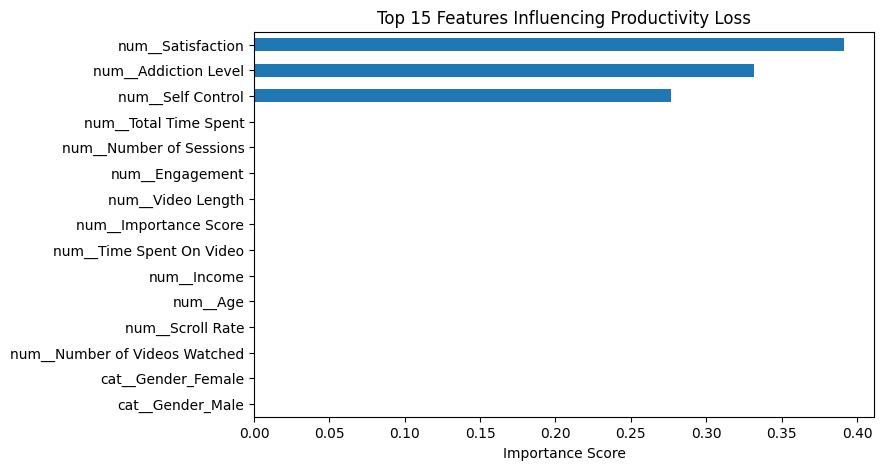

In [14]:
# Get feature importances from RandomForest
importances = pd.Series(best_pipe.named_steps["model"].feature_importances_,
                        index=best_pipe.named_steps["preprocess"].get_feature_names_out())

# Plot top 15 features
importances.sort_values(ascending=False).head(15).iloc[::-1].plot(kind="barh", figsize=(8,5))
plt.title("Top 15 Features Influencing Productivity Loss")
plt.xlabel("Importance Score")
plt.show()


In [15]:
import joblib
joblib.dump(best_pipe, "productivity_loss_model.joblib")


['productivity_loss_model.joblib']

In [16]:
loaded_model = joblib.load("productivity_loss_model.joblib")

# Make sure new_data has same columns as training X
new_data = X_test.head(5)  
preds = loaded_model.predict(new_data)
print(preds)


[7. 3. 9. 1. 8.]


In [19]:
print(loaded_model.named_steps.keys())


dict_keys(['preprocess', 'model'])


In [20]:
preprocessor = loaded_model.named_steps['preprocess']
print(preprocessor.get_feature_names_out())


['num__Age' 'num__Income' 'num__Total Time Spent'
 'num__Number of Sessions' 'num__Video Length' 'num__Engagement'
 'num__Importance Score' 'num__Time Spent On Video'
 'num__Number of Videos Watched' 'num__Scroll Rate' 'num__Satisfaction'
 'num__Self Control' 'num__Addiction Level' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__Gender_Other' 'cat__Location_Barzil'
 'cat__Location_Germany' 'cat__Location_India' 'cat__Location_Indonesia'
 'cat__Location_Japan' 'cat__Location_Mexico' 'cat__Location_Pakistan'
 'cat__Location_Philippines' 'cat__Location_United States'
 'cat__Location_Vietnam' 'cat__Debt_False' 'cat__Debt_True'
 'cat__Owns Property_False' 'cat__Owns Property_True'
 'cat__Profession_Artist' 'cat__Profession_Cashier'
 'cat__Profession_Engineer' 'cat__Profession_Labor/Worker'
 'cat__Profession_Manager' 'cat__Profession_Students'
 'cat__Profession_Teacher' 'cat__Profession_Waiting staff'
 'cat__Profession_driver' 'cat__Demographics_Rural'
 'cat__Demographics_Urban' 'cat__Platfor

In [23]:
new_user = pd.DataFrame([{
    "Age": 22,
    "Gender": "Male",
    "Location": "India",
    "Income": 25000,
    "Debt": "No",
    "Owns Property": "No",
    "Profession": "Student",
    "Demographics": "Urban",
    "Platform": "Instagram",
    "Total Time Spent": 180,
    "Number of Sessions": 15,
    "Video Category": "Entertainment",
    "Video Length": 120,
    "Engagement": 1,  # numeric if encoded
    "Importance Score": 3,
    "Time Spent On Video": 100,
    "Number of Videos Watched": 30,
    "Scroll Rate": 0.8,
    "Frequency": "Evening",
    "Satisfaction": 4,
    "Watch Reason": "Entertainment",
    "Self Control": 2,
    "Addiction Level": 4,
    # Fill missing columns with defaults
    "ConnectionType": "Wi-Fi",
    "CurrentActivity": "Studying",
    "OS": "Android",
    "DeviceType": "Mobile",
    "Watch Time": "Evening"
}])


In [24]:
print(df["ConnectionType"].unique())


['Mobile Data' 'Wi-Fi']


In [25]:
pred = best_pipe.predict(new_user)
print("Predicted Productivity Loss:", pred[0])


Predicted Productivity Loss: 3.6866666666666665


In [26]:
high_loss_user = pd.DataFrame([{
    "Age": 20,
    "Gender": "Male",
    "Location": "India",
    "Income": 15000,
    "Debt": "Yes",
    "Owns Property": "No",
    "Profession": "Student",
    "Demographics": "Urban",
    "Platform": "TikTok",
    "Total Time Spent": 600,             # much higher usage
    "Number of Sessions": 40,            # more sessions
    "Video Category": "Entertainment",
    "Video Length": 180,
    "Engagement": 5,                     # high engagement
    "Importance Score": 5,
    "Time Spent On Video": 500,
    "Number of Videos Watched": 100,     # lots of videos
    "Scroll Rate": 1.2,
    "Frequency": "Night",
    "Satisfaction": 5,
    "Watch Reason": "Entertainment",
    "Self Control": 1,                   # low self control
    "Addiction Level": 5,                # high addiction
    "ConnectionType": "Wi-Fi",
    "CurrentActivity": "Procrastinating",
    "OS": "Android",
    "DeviceType": "Mobile",
    "Watch Time": "Night"
}])

pred_high = best_pipe.predict(high_loss_user)
print("Predicted Productivity Loss (high):", pred_high[0])


Predicted Productivity Loss (high): 3.4266666666666667


In [27]:
print(df["ProductivityLoss"].min(), df["ProductivityLoss"].max())
print(df["ProductivityLoss"].describe())


1 9
count    1000.000000
mean        5.136000
std         2.122265
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max         9.000000
Name: ProductivityLoss, dtype: float64


In [28]:
preds = best_pipe.predict(X_test)
print(preds.min(), preds.max())


1.0 9.0


In [29]:
importances = pd.Series(
    best_pipe.named_steps["model"].feature_importances_,
    index=best_pipe.named_steps["preprocess"].get_feature_names_out()
)
print(importances.sort_values(ascending=False).head(15))


num__Satisfaction                0.391685
num__Addiction Level             0.331772
num__Self Control                0.276544
num__Total Time Spent            0.000000
num__Number of Sessions          0.000000
num__Engagement                  0.000000
num__Video Length                0.000000
num__Importance Score            0.000000
num__Time Spent On Video         0.000000
num__Income                      0.000000
num__Age                         0.000000
num__Scroll Rate                 0.000000
num__Number of Videos Watched    0.000000
cat__Gender_Female               0.000000
cat__Gender_Male                 0.000000
dtype: float64


In [30]:
high_loss_user = pd.DataFrame([{
    "Age": 19,
    "Gender": "Male",
    "Location": "India",
    "Income": 10000,
    "Debt": "Yes",
    "Owns Property": "No",
    "Profession": "Student",
    "Demographics": "Urban",
    "Platform": "TikTok",
    "Total Time Spent": 500, 
    "Number of Sessions": 40,
    "Video Category": "Entertainment",
    "Video Length": 200,
    "Engagement": 5,
    "Importance Score": 5,
    "Time Spent On Video": 400,
    "Number of Videos Watched": 150,
    "Scroll Rate": 1.0,
    "Frequency": "Night",
    "Satisfaction": 9,        # 🔥 high satisfaction
    "Watch Reason": "Entertainment",
    "Self Control": 1,        # 🔥 very low self control
    "Addiction Level": 9,     # 🔥 very high addiction
    "ConnectionType": "Wi-Fi",
    "CurrentActivity": "Procrastinating",
    "OS": "Android",
    "DeviceType": "Mobile",
    "Watch Time": "Night"
}])


In [31]:
pred_high = best_pipe.predict(high_loss_user)
print("Predicted Productivity Loss (high):", pred_high[0])

Predicted Productivity Loss (high): 1.0
